# IS467 @ MLC 597 - Dr. Hal Tibebu Lab
# Model Explainability with SHAP & LIME — Hands-On Lab

**Course:** Machine Learning / AI — Model Interpretability & Explainability  
**Tools:** SHAP (SHapley Additive exPlanations) & LIME (Local Interpretable Model-agnostic Explanations)

---

## Learning Objectives

1. Train a black-box classifier on real census survey data and evaluate performance under class imbalance.
2. Apply SHAP (global + local) to understand which features drive predictions.
3. Apply LIME to explain individual predictions via local linear approximations.
4. Compare SHAP and LIME — theoretical grounding, consistency, interpretability trade-offs.
5. Conduct intersectional bias analysis: examine how model accuracy and SHAP attributions differ across demographic subgroups (race × sex × education).

---

## Dataset

**Source:** American Community Survey (ACS) PUMS 2018 — Texas  
**Reference:** Ding et al. (2021), "Retiring Adult: New Datasets for Fair Machine Learning" (NeurIPS)  
**Access:** via the `folktables` library — a standard benchmark dataset for algorithmic fairness research

**Target:** `income` — whether an individual's annual personal income exceeds $50,000 (`>50K` vs `<=50K`).

| Feature | ACS Code | Type | Description |
|---|---|---|---|
| `age` | AGEP | int | Age in years |
| `workclass` | COW | categorical | Class of employer: Private, Government, Self-Employed, Other |
| `education` | SCHL | categorical | Highest educational attainment (No-HS → Graduate) |
| `education_years` | SCHL | int | Ordinal education code (1–24; higher = more education) |
| `marital_status` | MAR | categorical | Current marital status |
| `occupation` | OCCP | categorical | Major occupation group (grouped from 500+ ACS codes) |
| `relationship` | RELP | categorical | Household relationship role |
| `race` | RAC1P | categorical | Self-identified race — **sensitive attribute** |
| `sex` | SEX | categorical | Binary sex — **sensitive attribute** |
| `hours_per_week` | WKHP | int | Usual hours worked per week |
| `native_region` | POBP | categorical | Region of birth |
| `income` | PINCP>50K | target | `>50K` or `<=50K` annual personal income |



---
## Part 1: Environment Setup

In [74]:
!pip install shap lime folktables -q

/Users/dvgenis/.zshenv:.:1: no such file or directory: /var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/cursor-sandbox-cache/048d0f1034c67a180f3455d4f39f3313/cargo/env
pyenv: pip: command not found

The `pip' command exists in these Python versions:
  3.12.7

Note: See 'pyenv help global' for tips on allowing both
      python2 and python3 to be found.


In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, ConfusionMatrixDisplay
)
import shap
import lime
import lime.lime_tabular
import warnings
%pip install lime
warnings.filterwarnings('ignore')

print(f"✅ Libraries loaded | SHAP {shap.__version__} | NumPy {np.__version__} | Pandas {pd.__version__}")

/Users/dvgenis/.zshenv:.:1: no such file or directory: /var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/cursor-sandbox-cache/048d0f1034c67a180f3455d4f39f3313/cargo/env

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ Libraries loaded | SHAP 0.50.0 | NumPy 2.3.5 | Pandas 2.3.3


---
## Part 2: Dataset Loading & Preprocessing

The `folktables` library provides access to U.S. Census ACS PUMS data formatted for fairness research.  
The **ACSIncome** task predicts whether an employed adult's personal income exceeds $50,000.  
We use the Texas 2018 1-Year sample — a large, racially diverse state with significant income variation.

In [76]:
%pip install folktables
from folktables import ACSDataSource, ACSIncome

print("🔄 Downloading ACS 2018 Texas data from Census Bureau (~40MB, allow 60s)...")
data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person')
acs_data = data_source.get_data(states=['TX'], download=True)

# ACSIncome extracts 10 features, applies adult_filter (AGEP>16, PINCP>100, WKHP>0),
# and sets target = (PINCP > 50000). NaN values in features are replaced with -1.
features_arr, labels_arr, _ = ACSIncome.df_to_numpy(acs_data)
df_raw = pd.DataFrame(features_arr, columns=ACSIncome.features)
# ACSIncome.features = ['AGEP','COW','SCHL','MAR','OCCP','POBP','RELP','WKHP','SEX','RAC1P']
df_raw['label'] = labels_arr.astype(int)

print(f"✅ Raw data: {len(df_raw):,} rows")
# print dataframe
df_raw.head()

/Users/dvgenis/.zshenv:.:1: no such file or directory: /var/folders/jb/4gkhgpz15bbgklmqj7_zh0hm0000gn/T/cursor-sandbox-cache/048d0f1034c67a180f3455d4f39f3313/cargo/env

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
🔄 Downloading ACS 2018 Texas data from Census Bureau (~40MB, allow 60s)...
✅ Raw data: 135,924 rows


,AGEP,COW,SCHL,MAR,OCCP,POBP,RELP,WKHP,SEX,RAC1P,label
0,21.0,3.0,16.0,5.0,3500.0,48.0,17.0,10.0,2.0,2.0,0
1,20.0,1.0,16.0,5.0,4720.0,39.0,17.0,50.0,2.0,1.0,0
2,31.0,1.0,17.0,5.0,4110.0,48.0,17.0,30.0,1.0,1.0,0
3,39.0,1.0,21.0,1.0,4255.0,18.0,16.0,40.0,1.0,1.0,0
4,18.0,1.0,16.0,5.0,4055.0,48.0,17.0,20.0,1.0,6.0,0


In [77]:
# ── Decode ACS numeric codes to human-readable labels ─────────────────────

# RAC1P: 1=White, 2=Black or African American, 3-5=American Indian/Alaska Native,
#         6=Asian, 7=Native Hawaiian/Pacific Islander, 8=Other, 9=Two or more races
race_map = {1:'White', 2:'Black', 3:'Other', 4:'Other', 5:'Other',
            6:'Asian', 7:'Other', 8:'Other', 9:'Other'}

# SEX: 1=Male, 2=Female
sex_map = {1:'Male', 2:'Female'}

# MAR: 1=Married, 2=Widowed, 3=Divorced, 4=Separated, 5=Never married
mar_map = {1:'Married', 2:'Widowed', 3:'Divorced', 4:'Separated', 5:'Never-married'}

# COW: 1-2=Private (for-profit/non-profit), 3-5=Government (local/state/federal),
#       6-7=Self-Employed (incorporated/not), 8-9=Other/Unpaid
cow_map = {1:'Private', 2:'Private', 3:'Government', 4:'Government', 5:'Government',
           6:'Self-Employed', 7:'Self-Employed', 8:'Other', 9:'Other'}

# SCHL: 01-15=no diploma, 16=HS diploma/GED, 17-19=some college, 20=Assoc,
#        21=Bachelors, 22=Masters, 23=Professional degree, 24=Doctorate
def schl_cat(s):
    s = int(s)
    if s < 0:   return 'Unknown'
    elif s < 16: return 'No-HS'
    elif s == 16: return 'HS-grad'
    elif s <= 19: return 'Some-College'
    elif s == 20: return 'Assoc-degree'
    elif s == 21: return 'Bachelors'
    else:         return 'Graduate'   # Masters(22), Professional(23), Doctorate(24)

# OCCP: 0010-0430=Mgmt, 0500-0960=Business/Finance, 1000-1965=Computer/Eng/Science,
#        2000-2960=Education/Legal/Arts, 3000-3550=Healthcare practitioners,
#        3600-4650=Service, 4700-4965=Sales, 5000-5940=Office/Admin,
#        6000-6940=Farming/Construction, 7000-9760=Production/Transport
def occp_cat(code):
    if code < 0: return 'Other'    # -1 = was NaN (folktables fills NaN with -1)
    c = int(code)
    if c < 1000:   return 'Management'
    elif c < 3000:  return 'Professional'
    elif c < 4000:  return 'Healthcare-Service'
    elif c < 5000:  return 'Sales-Office'
    elif c < 7000:  return 'Craft-Labor'
    else:           return 'Transport-Production'

# RELP: 0=Reference person, 1=Spouse, 2-4=Child, 5-9=Other relative,
#        10-11=Non-relative, 12=Unmarried partner, 13-15=Group quarters
def relp_cat(r):
    r = int(r)
    if r == 0:            return 'Ref-person'
    elif r == 1:           return 'Spouse'
    elif r in [2, 3, 4]:  return 'Own-child'
    elif r in [5,6,7,8,9]: return 'Other-relative'
    elif r == 12:          return 'Unmarried-partner'
    else:                  return 'Not-in-family'

# POBP: 01-99=US states/territories, 100-199=Europe, 200-299=Asia,
#        300-379=Latin America, 380-399=South America, 400+=Africa/Other
def pobp_cat(p):
    p = int(p)
    if p <= 99:   return 'United-States'
    elif p <= 199: return 'Europe'
    elif p <= 299: return 'Asia'
    elif p <= 379: return 'Latin-America'
    elif p <= 399: return 'South-America'
    else:          return 'Africa-Other'

# Apply all mappings
df_raw['race']            = df_raw['RAC1P'].map(race_map)
df_raw['sex']             = df_raw['SEX'].map(sex_map)
df_raw['marital_status']  = df_raw['MAR'].map(mar_map)
df_raw['workclass']       = df_raw['COW'].map(cow_map)
df_raw['education']       = df_raw['SCHL'].apply(schl_cat)
df_raw['education_years'] = df_raw['SCHL'].astype(int).clip(lower=0)  # -1→0 for unknowns
df_raw['occupation']      = df_raw['OCCP'].apply(occp_cat)
df_raw['relationship']    = df_raw['RELP'].apply(relp_cat)
df_raw['native_region']   = df_raw['POBP'].apply(pobp_cat)
df_raw['income']          = df_raw['label'].map({1: '>50K', 0: '<=50K'})

# Build final DataFrame with renamed continuous columns
df = df_raw.rename(columns={'AGEP': 'age', 'WKHP': 'hours_per_week'})[
    ['age', 'workclass', 'education', 'education_years', 'marital_status',
     'occupation', 'relationship', 'race', 'sex', 'hours_per_week',
     'native_region', 'income']
].copy()

# Remove rows with missing data or invalid education codes
df = df[df['education_years'] > 0].dropna().reset_index(drop=True)

# Sample to 32,000 rows for speed (preserves class proportions)
if len(df) > 32000:
    df = df.sample(n=32000, random_state=42).reset_index(drop=True)

df.to_csv('income_survey.csv', index=False)
print(f"✅ Dataset saved as income_survey.csv")
print(f"   {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nIncome distribution:")
print(df['income'].value_counts())
print(df['income'].value_counts(normalize=True).round(3))

✅ Dataset saved as income_survey.csv
   32,000 rows × 12 columns

Income distribution:
income
<=50K    20169
>50K     11831
Name: count, dtype: int64
income
<=50K    0.63
>50K     0.37
Name: proportion, dtype: float64


In [108]:
print("DATASET INFO")
print("=" * 60)
df.info()
print()
print("NUMERICAL SUMMARY")
print("=" * 60)
df.describe()

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32000 entries, 0 to 31999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              32000 non-null  float64
 1   workclass        32000 non-null  int64  
 2   education        32000 non-null  int64  
 3   education_years  32000 non-null  int64  
 4   marital_status   32000 non-null  int64  
 5   occupation       32000 non-null  int64  
 6   relationship     32000 non-null  int64  
 7   race             32000 non-null  int64  
 8   sex              32000 non-null  int64  
 9   hours_per_week   32000 non-null  float64
 10  native_region    32000 non-null  int64  
 11  income           32000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 2.9 MB

NUMERICAL SUMMARY


,age,workclass,education,education_years,marital_status,occupation,relationship,race,sex,hours_per_week,native_region,income
count,32000.000000,32000.000000,32000.000000,32000.000000,32000.000000,32000.000000,32000.000000,32000.000000,32000.000000,32000.000000,32000.000000,32000.000000
mean,42.865375,1.816344,2.888594,18.237813,1.283125,2.615281,2.860656,2.595125,0.534500,39.695594,4.472531,0.369719
std,15.022036,0.803980,1.693856,3.726787,0.770338,1.716261,1.118550,0.846041,0.498816,13.011544,1.154383,0.482736
min,17.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,30.000000,2.000000,1.000000,16.000000,1.000000,1.000000,3.000000,3.000000,0.000000,38.000000,5.000000,0.000000
50%,42.000000,2.000000,3.000000,19.000000,1.000000,3.000000,3.000000,3.000000,1.000000,40.000000,5.000000,0.000000
75%,55.000000,2.000000,5.000000,21.000000,2.000000,4.000000,4.000000,3.000000,1.000000,45.000000,5.000000,1.000000
max,92.000000,3.000000,5.000000,24.000000,4.000000,5.000000,5.000000,3.000000,1.000000,99.000000,5.000000,1.000000


TARGET DISTRIBUTION
income
<=50K    20169
>50K     11831
Name: count, dtype: int64
income
<=50K    0.63
>50K     0.37
Name: proportion, dtype: float64


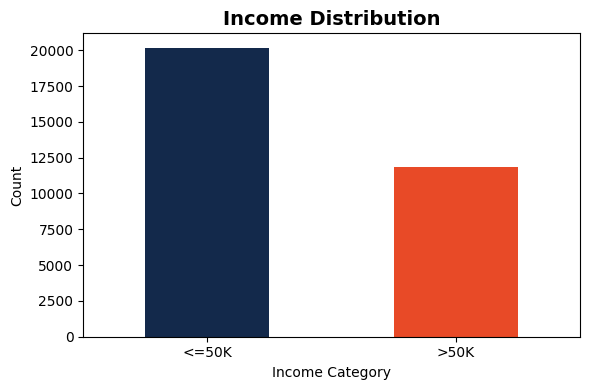

In [80]:
# Class imbalance is the key property here.
# A naive model predicting always <=50K achieves accuracy equal to the majority class fraction.
# This is why per-class metrics (precision, recall, F1) and fairness metrics (FNR by group)
# are more informative than overall accuracy on imbalanced data.
print("TARGET DISTRIBUTION")
print("=" * 40)
print(df['income'].value_counts())
print(df['income'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(6, 4))
df['income'].value_counts().plot(kind='bar', color=['#13294B', '#E84A27'], ax=ax)
ax.set_title('Income Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count'); ax.set_xlabel('Income Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

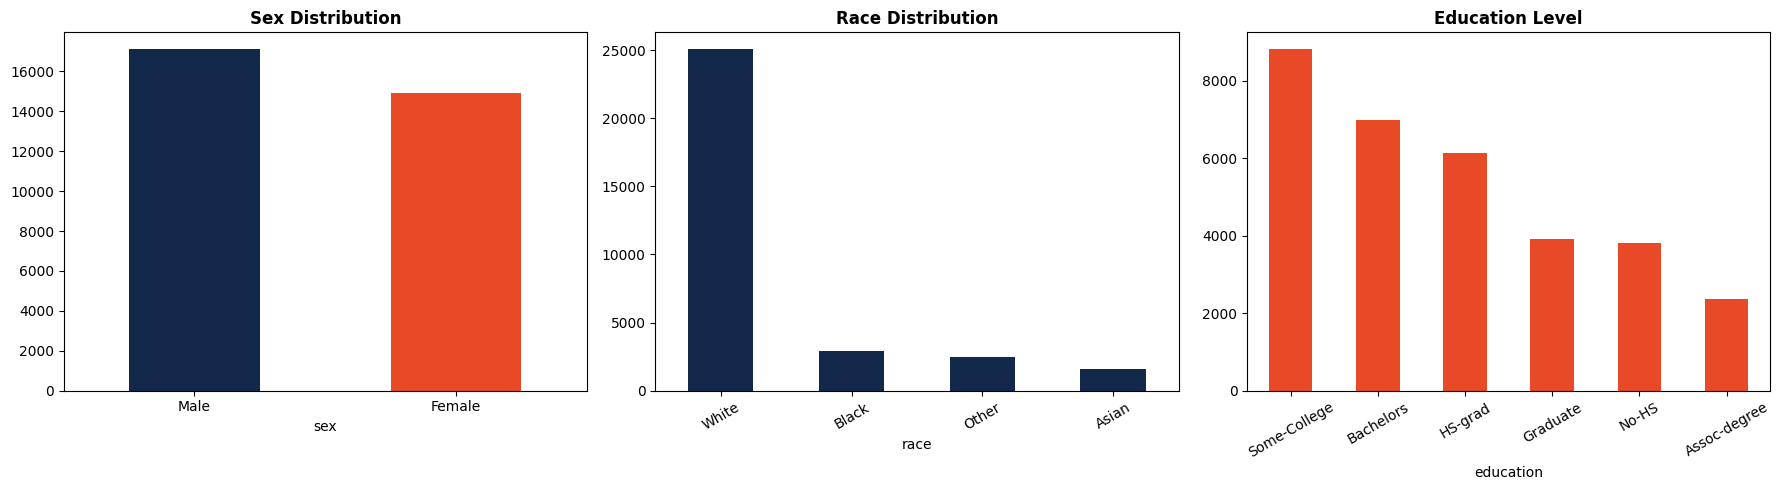

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df['sex'].value_counts().plot(kind='bar', ax=axes[0], color=['#13294B', '#E84A27'])
axes[0].set_title('Sex Distribution', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

df['race'].value_counts().plot(kind='bar', ax=axes[1], color='#13294B')
axes[1].set_title('Race Distribution', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

df['education'].value_counts().plot(kind='bar', ax=axes[2], color='#E84A27')
axes[2].set_title('Education Level', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
## Part 3: Preprocessing

In [82]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nRows with any missing: {df.isnull().any(axis=1).sum()}")
df = df.dropna()
print(f"✅ After drop: {df.shape[0]:,} rows remain")

Missing values per column:
age                0
workclass          0
education          0
education_years    0
marital_status     0
occupation         0
relationship       0
race               0
sex                0
hours_per_week     0
native_region      0
income             0
dtype: int64

Rows with any missing: 0
✅ After drop: 32,000 rows remain


In [83]:
# LabelEncoder assigns integers to category strings alphabetically.
# This is appropriate for tree-based models (GBM) which do not assume ordinal meaning
# from the integer labels. For linear models, use OneHotEncoder instead.
label_encoders = {}
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns:\n")
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print("\n✅ Encoding complete")

Encoding 9 categorical columns:

  workclass: {'Government': np.int64(0), 'Other': np.int64(1), 'Private': np.int64(2), 'Self-Employed': np.int64(3)}
  education: {'Assoc-degree': np.int64(0), 'Bachelors': np.int64(1), 'Graduate': np.int64(2), 'HS-grad': np.int64(3), 'No-HS': np.int64(4), 'Some-College': np.int64(5)}
  marital_status: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Never-married': np.int64(2), 'Separated': np.int64(3), 'Widowed': np.int64(4)}
  occupation: {'Craft-Labor': np.int64(0), 'Healthcare-Service': np.int64(1), 'Management': np.int64(2), 'Professional': np.int64(3), 'Sales-Office': np.int64(4), 'Transport-Production': np.int64(5)}
  relationship: {'Not-in-family': np.int64(0), 'Other-relative': np.int64(1), 'Own-child': np.int64(2), 'Ref-person': np.int64(3), 'Spouse': np.int64(4), 'Unmarried-partner': np.int64(5)}
  race: {'Asian': np.int64(0), 'Black': np.int64(1), 'Other': np.int64(2), 'White': np.int64(3)}
  sex: {'Female': np.int64(0), 'Male': np.int64(

In [84]:
X = df.drop(columns=['income'])
y = df['income']
print(f"Features: {X.shape}  |  Target: {y.shape}")
print(f"\nFeature names ({len(X.columns)}): {list(X.columns)}")

Features: (32000, 11)  |  Target: (32000,)

Feature names (11): ['age', 'workclass', 'education', 'education_years', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'hours_per_week', 'native_region']


In [85]:
# stratify=y preserves the class imbalance ratio in both train and test splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_test_reset = X_test.reset_index(drop=True)
y_test_reset  = y_test.reset_index(drop=True)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(3))

Train: 25,600  |  Test: 6,400

Class distribution in training set:
income
0    0.63
1    0.37
Name: proportion, dtype: float64


---
## Part 4: Training a Black-Box Model

**Gradient Boosting** builds an ensemble of shallow decision trees sequentially — each tree corrects the residual errors of the previous ensemble.  
High predictive accuracy but no direct interpretability — exactly the scenario where SHAP and LIME are needed.

In [109]:
# n_estimators=200: 200 sequential boosting rounds
# learning_rate=0.1: shrinkage per round — smaller values need more trees but generalize better
# max_depth=4: shallow trees reduce overfitting while allowing feature interactions
print("🔄 Training Gradient Boosting Classifier (200 estimators)...")
model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42
)
model.fit(X_train, y_train)
print("✅ Training complete")

🔄 Training Gradient Boosting Classifier (200 estimators)...
✅ Training complete


In [87]:
y_pred = model.predict(X_test)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("CLASSIFICATION REPORT")
print("=" * 60)
# On imbalanced data, focus on F1-score and recall for the minority class (>50K).
# High overall accuracy is achievable by predicting <=50K for everyone —
# the classification report reveals whether the model is actually learning the minority class.
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

Overall Accuracy: 0.7944

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       <=50K       0.83      0.85      0.84      4034
        >50K       0.73      0.71      0.72      2366

    accuracy                           0.79      6400
   macro avg       0.78      0.78      0.78      6400
weighted avg       0.79      0.79      0.79      6400



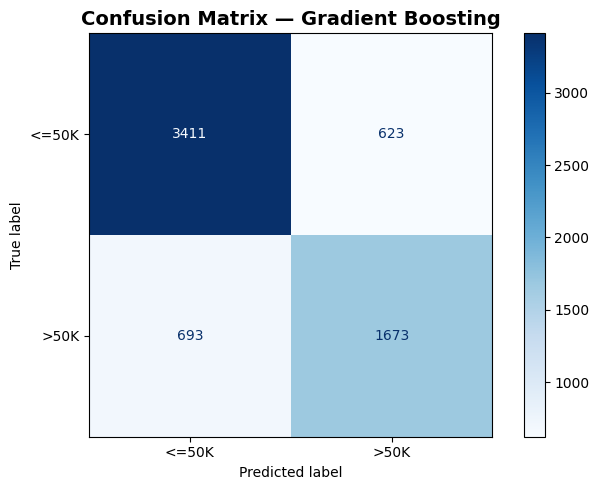

In [88]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['<=50K', '>50K'], cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Gradient Boosting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 5: SHAP — SHapley Additive exPlanations

SHAP is grounded in **cooperative game theory**. The Shapley value of a feature is its average marginal contribution to the model's prediction across all possible orderings of features being included.

For each prediction:
- **Positive SHAP value** → this feature pushed the prediction toward `>50K`
- **Negative SHAP value** → this feature pushed the prediction toward `<=50K`
- **Key property:** SHAP values for all features sum exactly to `f(x) − E[f(x)]` — the difference between the individual prediction and the average prediction (baseline)

**TreeExplainer** computes exact Shapley values by traversing the tree ensemble directly — orders of magnitude faster than the model-agnostic KernelExplainer.

In [89]:
print("🔄 Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(model)

print("🔄 Computing SHAP values for the test set...")
raw_shap = explainer.shap_values(X_test)
# For binary GBM, TreeExplainer returns a 2D array (positive class) in newer SHAP versions,
# or a list of two arrays in older versions. We always take the positive class (>50K).
shap_values = raw_shap[1] if isinstance(raw_shap, list) else raw_shap

print(f"✅ SHAP values: shape {shap_values.shape}")
print(f"   One row per test sample, one column per feature")


expected_value = explainer.expected_value

# Handle array case (binary classification)
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[0] if len(expected_value) == 1 else expected_value[1]

# Convert log-odds → probability
baseline_prob = 1 / (1 + np.exp(-expected_value))

print(f"   Baseline E[f(x)] (probability): {baseline_prob:.3f}")


🔄 Initializing SHAP TreeExplainer...
🔄 Computing SHAP values for the test set...
✅ SHAP values: shape (6400, 11)
   One row per test sample, one column per feature
   Baseline E[f(x)] (probability): 0.255


### Global Explanations

Global explanations aggregate SHAP values across all test samples: **which features matter most overall, and in which direction?**


SHAP SUMMARY PLOT — each dot = one test sample


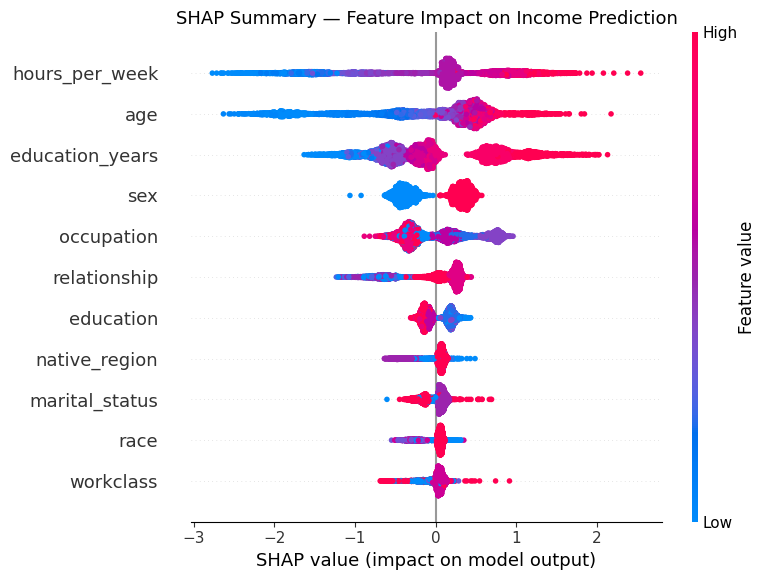

In [90]:
# Beeswarm summary plot — the most information-dense SHAP visualization:
# Y-axis: features sorted by mean |SHAP value| — most impactful features at top.
# X-axis: SHAP value — how much this feature instance shifted the prediction.
# Color: feature value (red = high, blue = low).
# Each dot = one test sample. Horizontal spread shows the range of effects across people.
#
# Reading example: if red dots (high age) cluster on the right side → higher age
# strongly and consistently pushes predictions toward >50K.
print("SHAP SUMMARY PLOT — each dot = one test sample")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), show=False)
plt.title("SHAP Summary — Feature Impact on Income Prediction", fontsize=13)
plt.tight_layout()
plt.show()

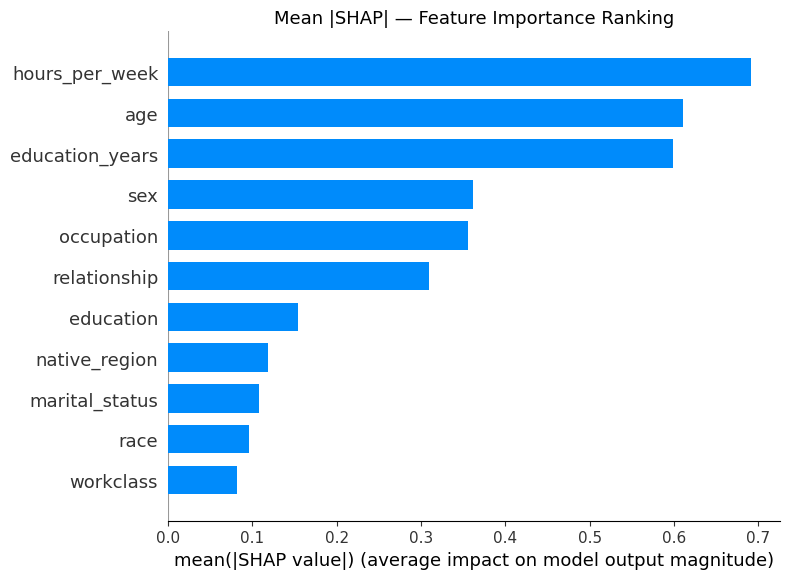

In [91]:
# Bar plot: mean |SHAP value| across all test samples.
# Unlike the beeswarm, this collapses direction — it answers "what matters most"
# but not "in what direction." A feature can have high mean |SHAP| but mixed
# effects (positive for some people, negative for others).
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(),
                  plot_type="bar", show=False)
plt.title("Mean |SHAP| — Feature Importance Ranking", fontsize=13)
plt.tight_layout()
plt.show()

### Local Explanations

Local explanations answer: **why did the model make this specific prediction for this specific person?**


In [92]:
pred_high = int(np.where(y_pred == 1)[0][0])
pred_low  = int(np.where(y_pred == 0)[0][0])

def decode_person(row):
    return {col: (label_encoders[col].inverse_transform([int(row[col])])[0]
                  if col in label_encoders else int(row[col]))
            for col in row.index}

print("=" * 60)
print(f"Sample #{pred_high} — Predicted: >50K")
print("=" * 60)
for k, v in decode_person(X_test_reset.iloc[pred_high]).items():
    print(f"  {k:<20} {v}")
print(f"\n  Prediction: {'> 50K' if y_pred[pred_high]==1 else '<= 50K'}")
print(f"  Actual:     {'> 50K' if y_test_reset.iloc[pred_high]==1 else '<= 50K'}")

Sample #2 — Predicted: >50K
  age                  34
  workclass            Government
  education            Graduate
  education_years      22
  marital_status       Never-married
  occupation           Professional
  relationship         Ref-person
  race                 Black
  sex                  Female
  hours_per_week       41
  native_region        United-States

  Prediction: > 50K
  Actual:     > 50K


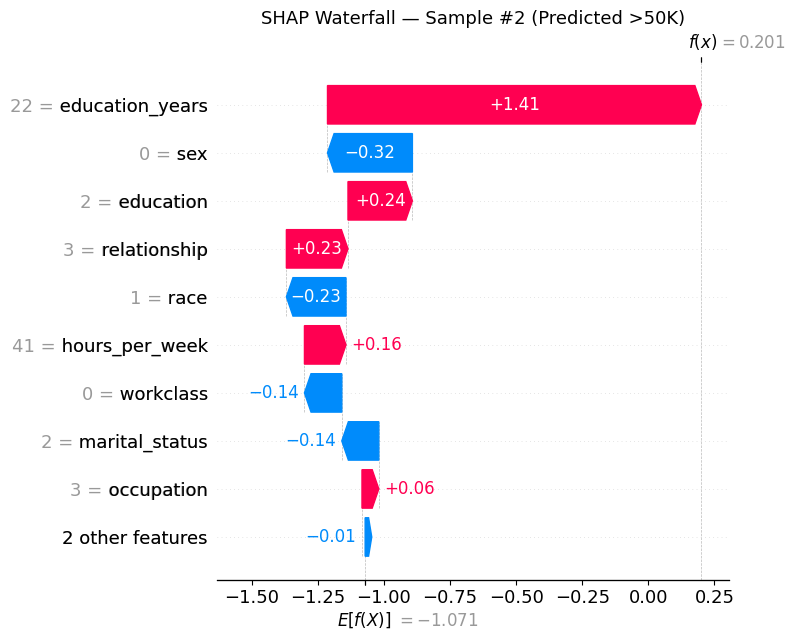

In [93]:
# Waterfall plot: step-by-step attribution for one individual.
# Starts at E[f(x)] — the model's average output across training data (baseline).
# Each horizontal bar shows how much that feature shifted the running total.
# The final value f(x) is the model's actual log-odds output for this person.
# Red bars → pushed toward >50K; Blue bars → pushed toward <=50K.
# The bar width = SHAP value magnitude; direction = sign of SHAP value.
shap_exp_high = shap.Explanation(
    values=shap_values[pred_high],
    base_values=explainer.expected_value,
    data=X_test_reset.iloc[pred_high].values,
    feature_names=X.columns.tolist()
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_exp_high, show=False)
plt.title(f"SHAP Waterfall — Sample #{pred_high} (Predicted >50K)", fontsize=13)
plt.tight_layout()
plt.show()

Sample #0 — Predicted: <=50K
  age                  52
  workclass            Self-Employed
  education            Some-College
  education_years      19
  marital_status       Married
  occupation           Sales-Office
  relationship         Spouse
  race                 White
  sex                  Female
  hours_per_week       30
  native_region        United-States

  Prediction: <= 50K
  Actual:     <= 50K


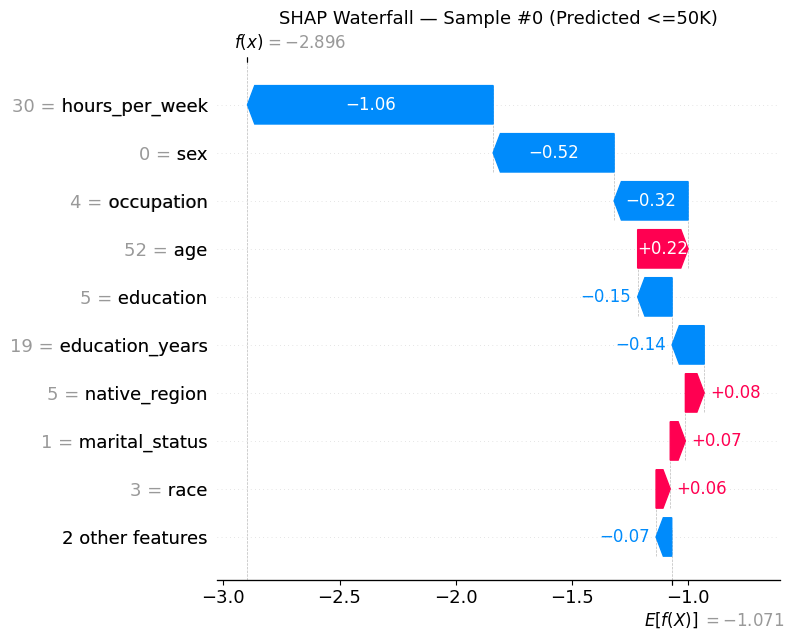

In [94]:
print(f"Sample #{pred_low} — Predicted: <=50K")
for k, v in decode_person(X_test_reset.iloc[pred_low]).items():
    print(f"  {k:<20} {v}")
print(f"\n  Prediction: {'> 50K' if y_pred[pred_low]==1 else '<= 50K'}")
print(f"  Actual:     {'> 50K' if y_test_reset.iloc[pred_low]==1 else '<= 50K'}")

shap_exp_low = shap.Explanation(
    values=shap_values[pred_low],
    base_values=explainer.expected_value,
    data=X_test_reset.iloc[pred_low].values,
    feature_names=X.columns.tolist()
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_exp_low, show=False)
plt.title(f"SHAP Waterfall — Sample #{pred_low} (Predicted <=50K)", fontsize=13)
plt.tight_layout()
plt.show()

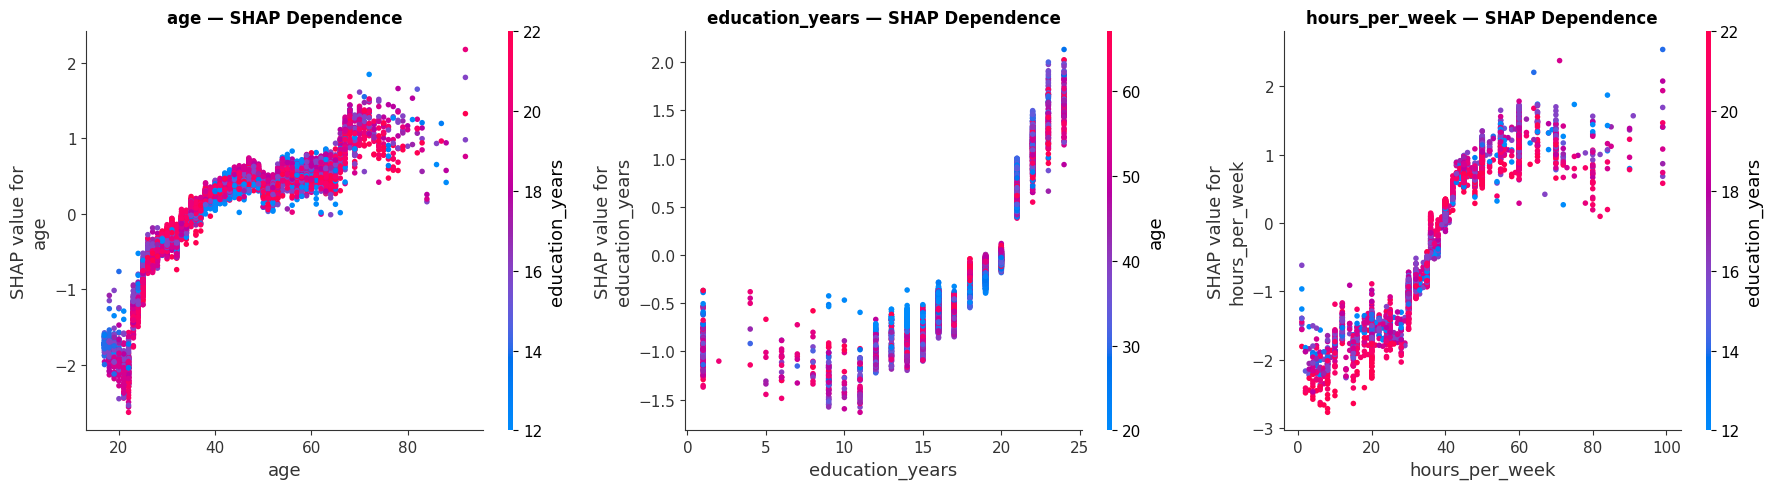

In [95]:
# Dependence plot: how a single feature's value (x-axis) relates to its SHAP value (y-axis).
# The color encodes a second feature — the one with the strongest interaction effect
# (automatically selected by SHAP). Look for:
#   - Non-linearity: curved or step-shaped relationships
#   - Thresholds: sharp jumps at particular feature values
#   - Interaction effects: color-based splits (different colored bands at the same x-value)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, ['age', 'education_years', 'hours_per_week']):
    shap.dependence_plot(feat, shap_values, X_test,
                         feature_names=X.columns.tolist(), ax=ax, show=False)
    ax.set_title(f"{feat} — SHAP Dependence", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 6: LIME — Local Interpretable Model-agnostic Explanations

LIME explains individual predictions by:
1. **Perturbing** the instance: generating many nearby modified versions
2. **Querying** the black-box model on each perturbed version
3. **Fitting a weighted linear model** to the (perturbed input, model output) pairs — weighted by proximity to the original
4. **Reading off** the linear coefficients as feature importances

Core assumption: even a highly non-linear global model can be well approximated *locally* (near any specific point) by a simple linear model.

| | SHAP | LIME |
|---|---|---|
| **Theoretical basis** | Game theory (Shapley values) | Local linear surrogate |
| **Guarantee** | Exact, mathematically consistent | Approximate, stochastic |
| **Scope** | Global + Local | Local only |
| **Output format** | Numeric contributions summing to prediction | If-then rule weights |
| **Speed (tree models)** | Fast (exploits tree structure) | Slower (model-agnostic sampling) |

In [96]:
# training_data: defines the feature distribution used to generate perturbations
# discretize_continuous=True: bins numeric features into ranges, producing
#   human-readable rules like "age > 45" instead of raw numeric contributions
print("🔄 Initializing LIME Tabular Explainer...")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X.columns.tolist(),
    class_names=['<=50K', '>50K'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)
print(f"✅ LIME ready | Training shape: {X_train.shape}")

🔄 Initializing LIME Tabular Explainer...
✅ LIME ready | Training shape: (25600, 11)


LIME EXPLANATION — Sample #2 (Predicted: >50K)



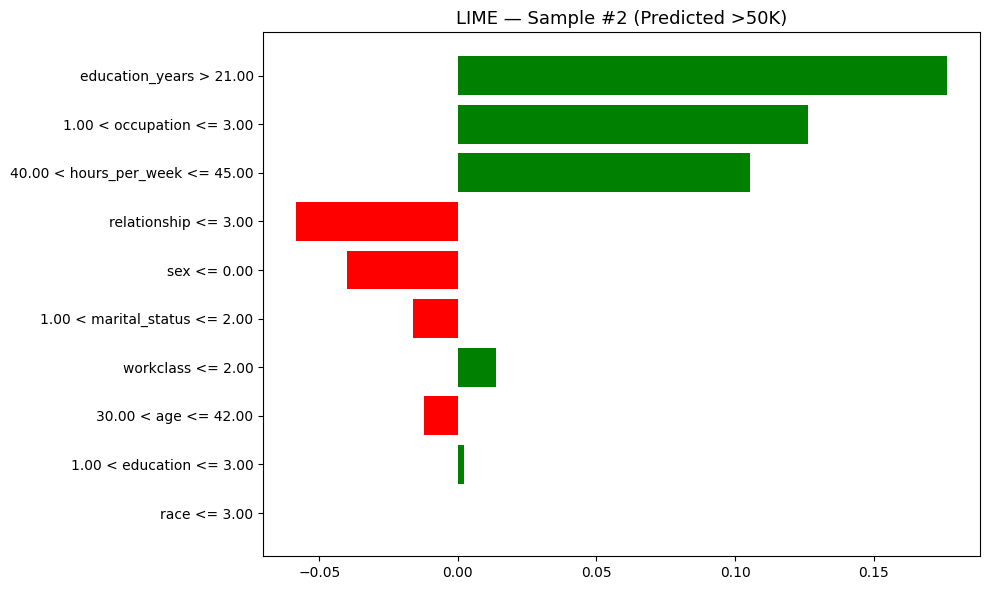


Probabilities: <=50K = 0.450,  >50K = 0.550

Rank  Feature Condition                            Weight
---------------------------------------------------------
1     education_years > 21.00                     +0.1766
2     1.00 < occupation <= 3.00                   +0.1264
3     40.00 < hours_per_week <= 45.00             +0.1055
4     relationship <= 3.00                        -0.0584
5     sex <= 0.00                                 -0.0400
6     1.00 < marital_status <= 2.00               -0.0160
7     workclass <= 2.00                           +0.0138
8     30.00 < age <= 42.00                        -0.0122
9     1.00 < education <= 3.00                    +0.0020
10    race <= 3.00                                +0.0000


In [97]:
print(f"LIME EXPLANATION — Sample #{pred_high} (Predicted: >50K)\n")
# num_samples=5000: more perturbations → more stable local linear approximation
lime_exp_high = lime_explainer.explain_instance(
    data_row=X_test_reset.iloc[pred_high].values,
    predict_fn=model.predict_proba,
    num_features=10, num_samples=5000
)
fig = lime_exp_high.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title(f"LIME — Sample #{pred_high} (Predicted >50K)", fontsize=13)
plt.tight_layout()
plt.show()

# Green bars → push toward >50K; Red bars → push toward <=50K.
# The rule (e.g., "education_years > 20") describes the feature's actual value range.
# Weight magnitude = importance in the local linear approximation for this individual.
print(f"\nProbabilities: <=50K = {lime_exp_high.predict_proba[0]:.3f},  "
      f">50K = {lime_exp_high.predict_proba[1]:.3f}")
print(f"\n{'Rank':<5} {'Feature Condition':<40} {'Weight':>10}")
print("-" * 57)
for rank, (rule, weight) in enumerate(lime_exp_high.as_list(), 1):
    print(f"{rank:<5} {rule:<40} {weight:>+10.4f}")

LIME EXPLANATION — Sample #0 (Predicted: <=50K)



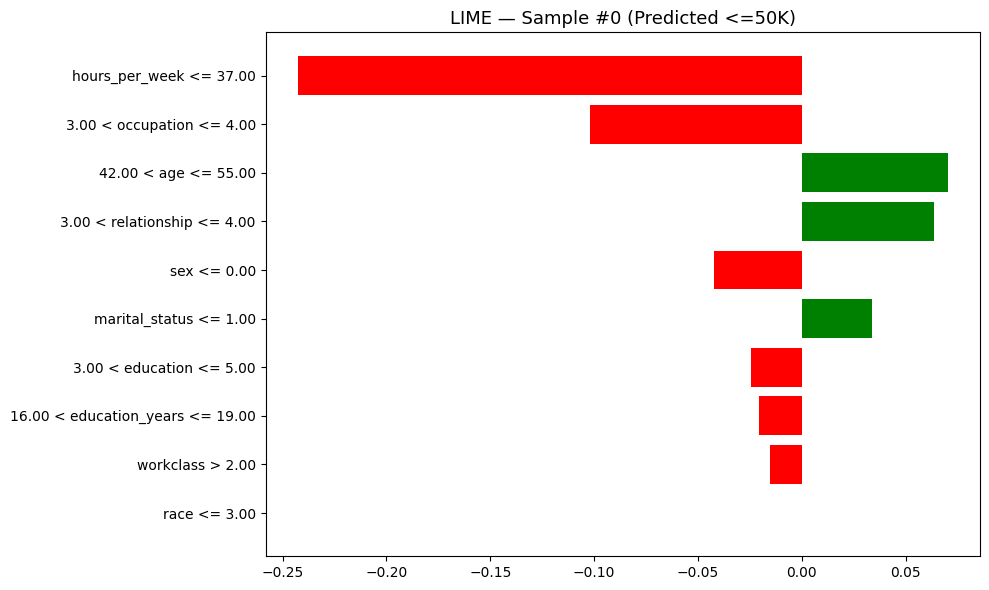


Probabilities: <=50K = 0.948,  >50K = 0.052

Rank  Feature Condition                            Weight
---------------------------------------------------------
1     hours_per_week <= 37.00                     -0.2426
2     3.00 < occupation <= 4.00                   -0.1017
3     42.00 < age <= 55.00                        +0.0702
4     3.00 < relationship <= 4.00                 +0.0639
5     sex <= 0.00                                 -0.0423
6     marital_status <= 1.00                      +0.0339
7     3.00 < education <= 5.00                    -0.0243
8     16.00 < education_years <= 19.00            -0.0206
9     workclass > 2.00                            -0.0152
10    race <= 3.00                                +0.0000


In [98]:
print(f"LIME EXPLANATION — Sample #{pred_low} (Predicted: <=50K)\n")
lime_exp_low = lime_explainer.explain_instance(
    data_row=X_test_reset.iloc[pred_low].values,
    predict_fn=model.predict_proba,
    num_features=10, num_samples=5000
)
fig = lime_exp_low.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.title(f"LIME — Sample #{pred_low} (Predicted <=50K)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nProbabilities: <=50K = {lime_exp_low.predict_proba[0]:.3f},  "
      f">50K = {lime_exp_low.predict_proba[1]:.3f}")
print(f"\n{'Rank':<5} {'Feature Condition':<40} {'Weight':>10}")
print("-" * 57)
for rank, (rule, weight) in enumerate(lime_exp_low.as_list(), 1):
    print(f"{rank:<5} {rule:<40} {weight:>+10.4f}")

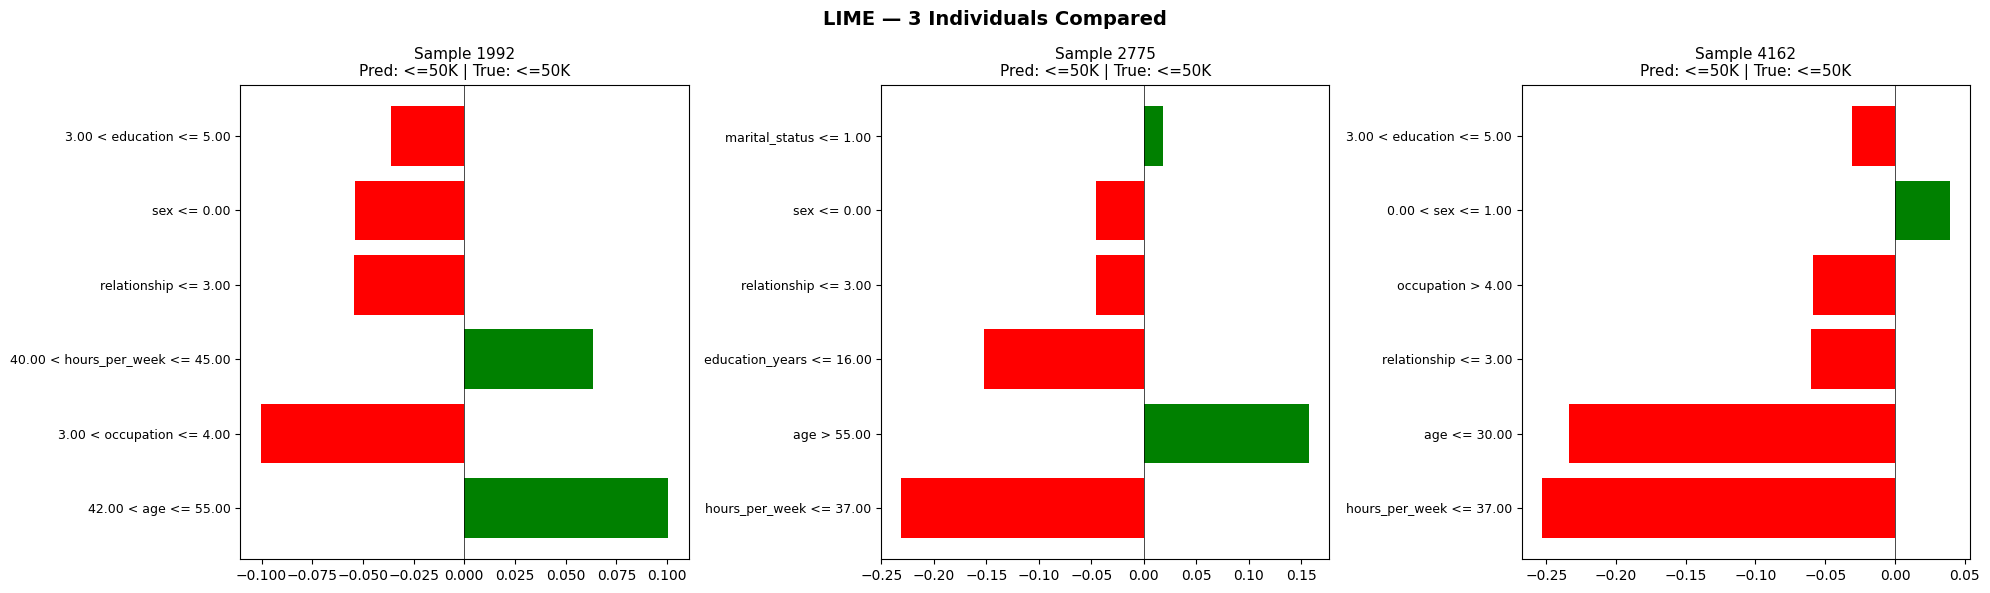

In [99]:
# Because LIME is LOCAL, each individual gets a genuinely different explanation —
# the local linear model is re-fitted around each specific point.
# This personalisation reveals cases where the model applies different decision logic
# to different subpopulations (a key signal for potential bias).
np.random.seed(42)
rand_idx = np.random.choice(len(X_test_reset), size=3, replace=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, idx in enumerate(rand_idx):
    exp = lime_explainer.explain_instance(
        X_test_reset.iloc[idx].values, model.predict_proba,
        num_features=6, num_samples=5000
    )
    pred_lbl = '<=50K' if y_pred[idx]==0 else '>50K'
    true_lbl = '<=50K' if y_test_reset.iloc[idx]==0 else '>50K'
    items = exp.as_list()
    if items:
        feats, wts = zip(*items)
        axes[i].barh(range(len(feats)), wts,
                     color=['green' if w>0 else 'red' for w in wts])
        axes[i].set_yticks(range(len(feats)))
        axes[i].set_yticklabels(feats, fontsize=9)
    axes[i].set_title(f"Sample {idx}\nPred: {pred_lbl} | True: {true_lbl}", fontsize=11)
    axes[i].axvline(x=0, color='black', linewidth=0.5)
plt.suptitle("LIME — 3 Individuals Compared", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 7: SHAP vs LIME — Side-by-Side Comparison

Both methods explain the same individual but via fundamentally different mechanisms.  
Agreement on top features signals robust attributions. Divergence warrants investigation — it may reflect LIME's local approximation error or features with non-linear effects that a local linear model captures poorly.

In [100]:
sample_idx = pred_high

shap_imp = pd.DataFrame({
    'feature': X.columns,
    'shap_value': shap_values[sample_idx]
}).sort_values('shap_value', key=abs, ascending=False)

lime_comp = lime_explainer.explain_instance(
    X_test_reset.iloc[sample_idx].values, model.predict_proba,
    num_features=len(X.columns), num_samples=5000
)
lime_imp = pd.DataFrame(lime_comp.as_list(), columns=['feature_rule', 'lime_weight'])

print("=" * 78)
print(f"SHAP vs LIME — Sample #{sample_idx}")
print("=" * 78)
print(f"{'SHAP Feature':<22} {'SHAP Value':>12}   {'LIME Rule':<28} {'LIME Weight':>11}")
print("-" * 78)
for i in range(min(10, len(shap_imp))):
    s = shap_imp.iloc[i]
    if i < len(lime_imp):
        l = lime_imp.iloc[i]
        print(f"{s['feature']:<22} {s['shap_value']:>+12.4f}   "
              f"{l['feature_rule'][:28]:<28} {l['lime_weight']:>+11.4f}")
    else:
        print(f"{s['feature']:<22} {s['shap_value']:>+12.4f}")

SHAP vs LIME — Sample #2
SHAP Feature             SHAP Value   LIME Rule                    LIME Weight
------------------------------------------------------------------------------
education_years             +1.4148   education_years > 21.00          +0.1881
sex                         -0.3212   1.00 < occupation <= 3.00        +0.1255
education                   +0.2437   40.00 < hours_per_week <= 45     +0.0929
relationship                +0.2331   sex <= 0.00                      -0.0527
race                        -0.2255   relationship <= 3.00             -0.0452
hours_per_week              +0.1572   1.00 < marital_status <= 2.0     -0.0299
workclass                   -0.1413   workclass <= 2.00                +0.0183
marital_status              -0.1401   1.00 < education <= 3.00         +0.0054
occupation                  +0.0637   30.00 < age <= 42.00             +0.0013
age                         -0.0622   native_region <= 5.00            +0.0000


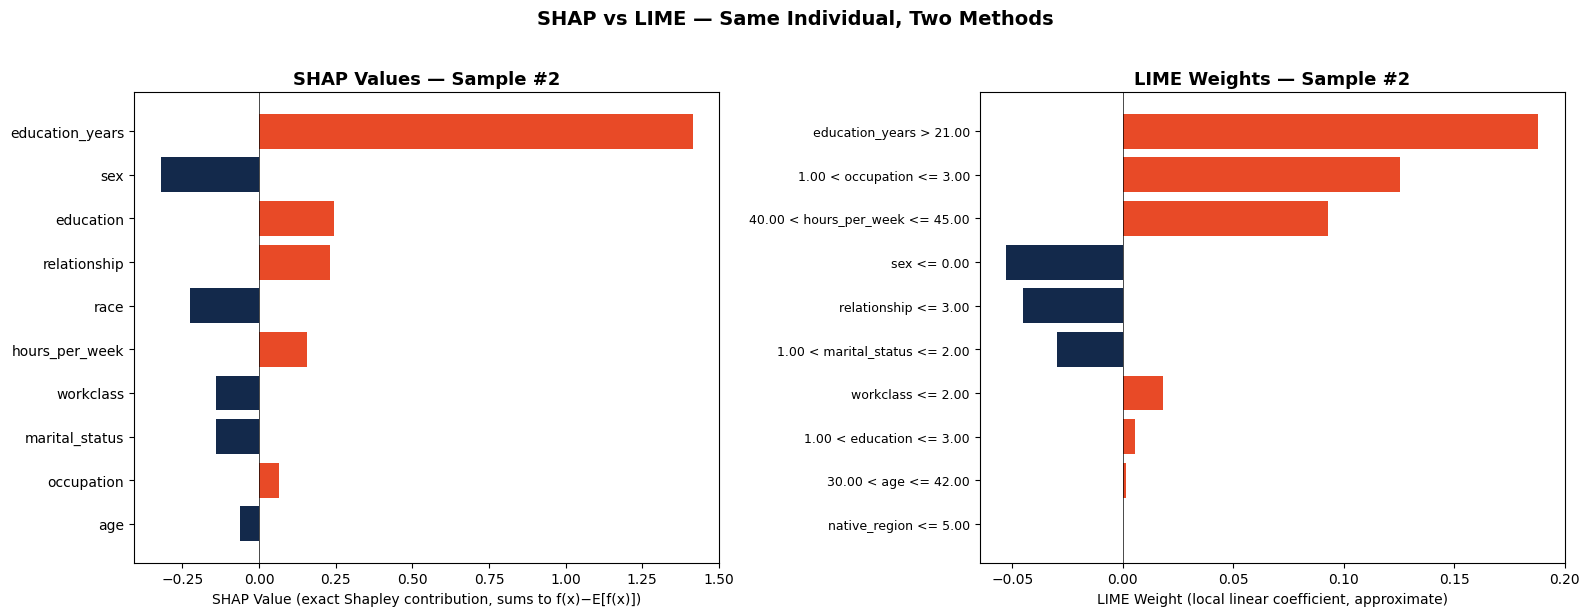

In [101]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
top_n = 10
shap_top = shap_imp.head(top_n).iloc[::-1]
lime_top  = lime_imp.head(top_n).iloc[::-1]

ax1.barh(range(len(shap_top)), shap_top['shap_value'],
          color=['#E84A27' if v>0 else '#13294B' for v in shap_top['shap_value']])
ax1.set_yticks(range(len(shap_top))); ax1.set_yticklabels(shap_top['feature'], fontsize=10)
ax1.set_title(f"SHAP Values — Sample #{sample_idx}", fontsize=13, fontweight='bold')
ax1.set_xlabel('SHAP Value (exact Shapley contribution, sums to f(x)−E[f(x)])')
ax1.axvline(x=0, color='black', linewidth=0.5)

ax2.barh(range(len(lime_top)), lime_top['lime_weight'],
          color=['#E84A27' if v>0 else '#13294B' for v in lime_top['lime_weight']])
ax2.set_yticks(range(len(lime_top))); ax2.set_yticklabels(lime_top['feature_rule'], fontsize=9)
ax2.set_title(f"LIME Weights — Sample #{sample_idx}", fontsize=13, fontweight='bold')
ax2.set_xlabel('LIME Weight (local linear coefficient, approximate)')
ax2.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('SHAP vs LIME — Same Individual, Two Methods', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# SHAP: exact, additive — values sum to f(x)−E[f(x)]; consistent across runs.
# LIME: approximate — coefficients from a local linear fit; vary slightly between runs.
# SHAP features show raw encoded values; LIME features show discretized rules.
# Directional agreement on top features = high confidence; divergence = investigate further.

---
## Part 8: Intersectional Fairness Analysis

Aggregate accuracy hides systematic errors in specific subgroups. **Intersectional analysis** examines groups defined by multiple demographic dimensions simultaneously (e.g., Black Female, not just Black or Female separately).

We analyze three layers:
1. **Accuracy and False Negative Rate (FNR)** by race × sex — who is most harmed by model errors?
2. **Accuracy and true income rate** by race × sex × education — does education yield equal returns across groups?
3. **Mean SHAP values** for sensitive features by group — are demographic attributes directly driving decisions?

In [102]:
# Decode race and sex labels for grouping
Xt = X_test_reset.copy()
Xt['y_true'] = y_test_reset.values
Xt['y_pred'] = y_pred
Xt['race_lbl'] = label_encoders['race'].inverse_transform(Xt['race'].astype(int))
Xt['sex_lbl']  = label_encoders['sex'].inverse_transform(Xt['sex'].astype(int))

# Education groups based on ACS SCHL ordinal scale (1-24):
# 1-15 = no HS diploma, 16 = HS diploma/GED, 17-20 = some college / Assoc, 21-24 = Bachelors+
Xt['edu_group'] = pd.cut(
    Xt['education_years'], bins=[0, 15, 16, 20, 24],
    labels=['<HS', 'HS-grad', 'Some-Col/Assoc', 'Bachelors+'],
    include_lowest=True
)

print(f"Test set: {len(Xt):,} samples")
print("\nGroup sizes (Race × Sex) — groups with N ≥ 30:")
sizes = Xt.groupby(['race_lbl', 'sex_lbl']).size()
print(sizes[sizes >= 30].to_string())

Test set: 6,400 samples

Group sizes (Race × Sex) — groups with N ≥ 30:
race_lbl  sex_lbl
Asian     Female      153
          Male        177
Black     Female      313
          Male        267
Other     Female      200
          Male        269
White     Female     2401
          Male       2620


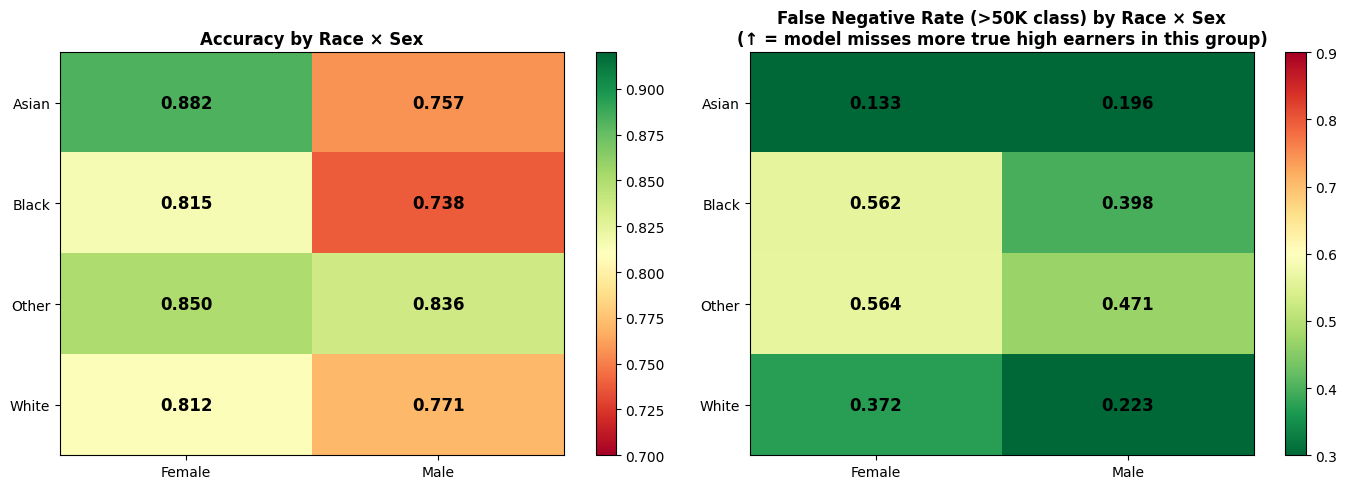


Full group summary:
 Race    Sex    N  Accuracy      FNR  TrueHighRate
Asian Female  153  0.882353 0.133333      0.392157
Asian   Male  177  0.757062 0.195876      0.548023
Black Female  313  0.814696 0.561644      0.233227
Black   Male  267  0.737828 0.397727      0.329588
Other Female  200  0.850000 0.564103      0.195000
Other   Male  269  0.836431 0.470588      0.252788
White Female 2401  0.811745 0.371758      0.289046
White   Male 2620  0.770611 0.222935      0.475954


In [103]:
# False Negative Rate (FNR) for the >50K class:
#   FNR = P(predicted <=50K | actual >50K)
# A group with high FNR has most of its true high-income members incorrectly
# labeled as low-income — a concrete form of algorithmic disadvantage.
# High accuracy + high FNR = model mostly predicts <=50K for this group,
# which appears "accurate" only because most group members do earn <=50K.

results = []
for (race, sex_lbl), grp in Xt.groupby(['race_lbl', 'sex_lbl']):
    if len(grp) < 30: continue
    hi      = grp['y_true'] == 1
    acc     = accuracy_score(grp['y_true'], grp['y_pred'])
    fnr     = (grp.loc[hi, 'y_pred'] == 0).mean() if hi.sum() > 0 else np.nan
    results.append({'Race': race, 'Sex': sex_lbl, 'N': len(grp),
                    'Accuracy': acc, 'FNR': fnr, 'TrueHighRate': hi.mean()})
res_df = pd.DataFrame(results)

acc_piv = res_df.pivot(index='Race', columns='Sex', values='Accuracy')
fnr_piv = res_df.pivot(index='Race', columns='Sex', values='FNR')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, piv, title, cmap, vmin, vmax in [
    (axes[0], acc_piv, 'Accuracy by Race × Sex', 'RdYlGn', 0.70, 0.92),
    (axes[1], fnr_piv,
     'False Negative Rate (>50K class) by Race × Sex\n'
     '(↑ = model misses more true high earners in this group)',
     'RdYlGn_r', 0.30, 0.90),
]:
    im = ax.imshow(piv.values, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    for i in range(len(piv.index)):
        for j in range(len(piv.columns)):
            val = piv.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                         fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax)
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nFull group summary:")
print(res_df[['Race','Sex','N','Accuracy','FNR','TrueHighRate']].to_string(index=False))

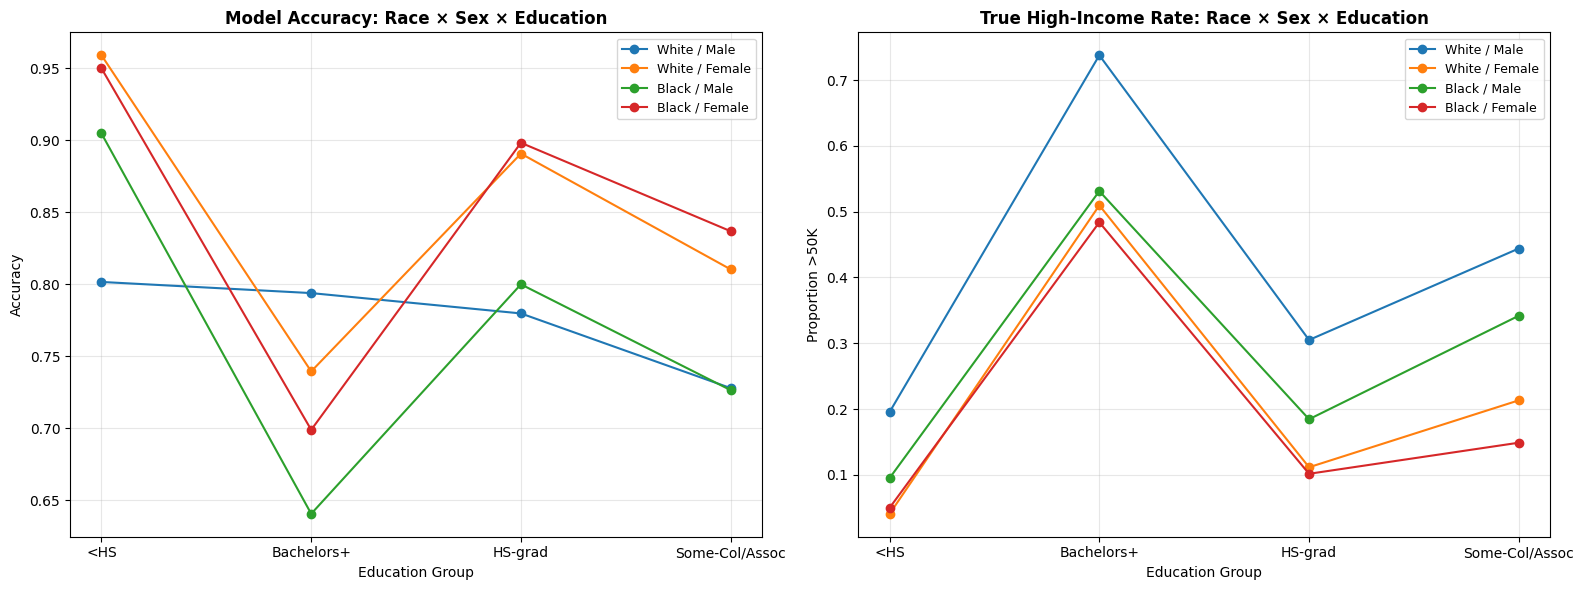


Detailed table (N ≥ 20):
         Group      Education   N  Accuracy  TrueHighRate
Asian / Female            <HS  21  0.857143      0.142857
Asian / Female     Bachelors+  96  0.864583      0.541667
Asian / Female Some-Col/Assoc  20  0.900000      0.250000
  Asian / Male            <HS  20  0.750000      0.200000
  Asian / Male     Bachelors+ 121  0.768595      0.677686
  Asian / Male Some-Col/Assoc  26  0.730769      0.307692
Black / Female            <HS  20  0.950000      0.050000
Black / Female     Bachelors+  93  0.698925      0.483871
Black / Female        HS-grad  59  0.898305      0.101695
Black / Female Some-Col/Assoc 141  0.836879      0.148936
  Black / Male            <HS  21  0.904762      0.095238
  Black / Male     Bachelors+  64  0.640625      0.531250
  Black / Male        HS-grad  65  0.800000      0.184615
  Black / Male Some-Col/Assoc 117  0.726496      0.341880
Other / Female            <HS  45  0.955556      0.044444
Other / Female     Bachelors+  40  0.700000   

In [104]:
# Three-way intersection: Race × Sex × Education.
# Key question: does more education close the gap — or does the model
# fail to equally "reward" education across demographic groups?

edu_results = []
for (race, sex_lbl, edu), grp in Xt.groupby(['race_lbl','sex_lbl','edu_group'], observed=True):
    if len(grp) < 20: continue
    edu_results.append({
        'Group': f"{race} / {sex_lbl}", 'Education': str(edu),
        'Accuracy': accuracy_score(grp['y_true'], grp['y_pred']),
        'TrueHighRate': (grp['y_true']==1).mean(), 'N': len(grp)
    })
edu_df = pd.DataFrame(edu_results)

focus = ['White / Male','White / Female','Black / Male','Black / Female']
edu_focus = edu_df[edu_df['Group'].isin(focus)]
color_map = {'White / Male':'#1f77b4','White / Female':'#ff7f0e',
             'Black / Male':'#2ca02c','Black / Female':'#d62728'}

# Also add Other group if sample is large enough
other_groups = [g for g in edu_df['Group'].unique()
                if g not in focus and edu_df[edu_df['Group']==g]['N'].sum() >= 80]
extra_colors = ['#9467bd','#8c564b','#e377c2']
for i, g in enumerate(other_groups[:2]):
    color_map[g] = extra_colors[i]
    focus_plot = focus + [g]
else:
    focus_plot = focus

edu_plot = edu_df[edu_df['Group'].isin(focus_plot)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for group in focus_plot:
    sub = edu_plot[edu_plot['Group']==group].sort_values('Education')
    if len(sub) >= 2:
        c = color_map.get(group, '#555555')
        axes[0].plot(sub['Education'], sub['Accuracy'],    marker='o', label=group, color=c)
        axes[1].plot(sub['Education'], sub['TrueHighRate'], marker='o', label=group, color=c)

axes[0].set_title('Model Accuracy: Race × Sex × Education', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Education Group'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_title('True High-Income Rate: Race × Sex × Education', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Education Group'); axes[1].set_ylabel('Proportion >50K')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDetailed table (N ≥ 20):")
print(edu_df[['Group','Education','N','Accuracy','TrueHighRate']].sort_values(
    ['Group','Education']).to_string(index=False))

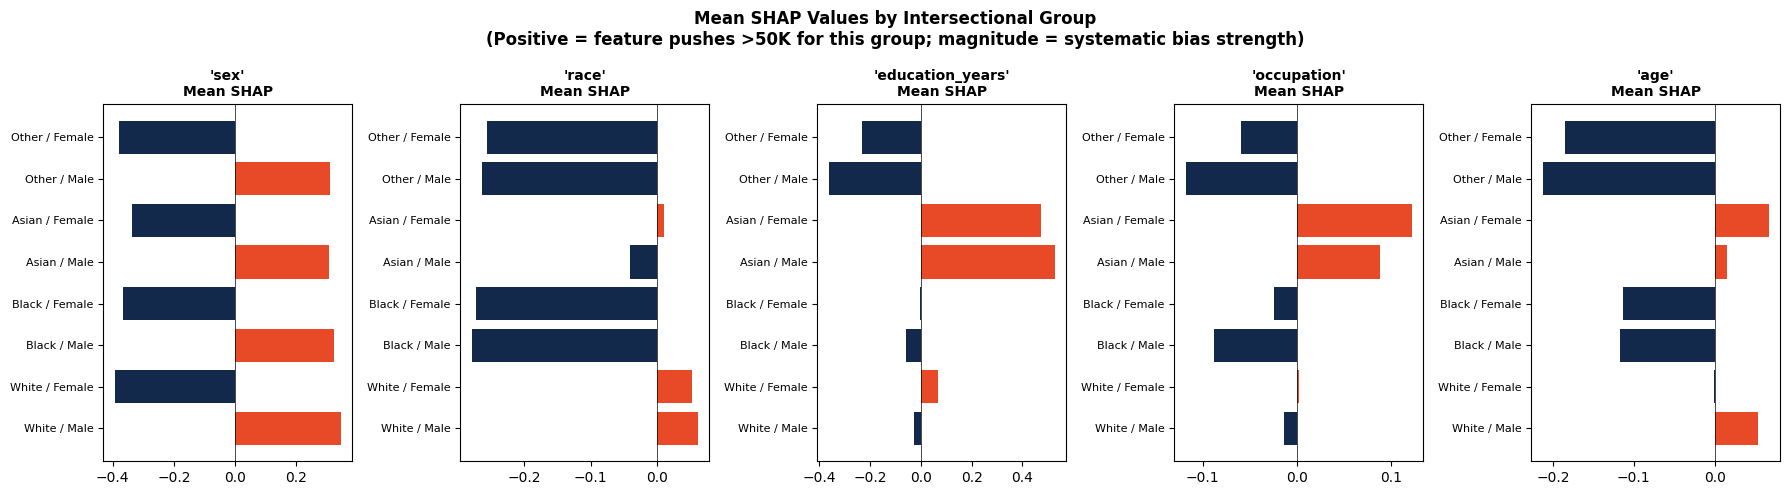


Mean SHAP table:
                   sex    race  education_years  occupation     age
group                                                              
White / Male    0.3452  0.0613          -0.0269     -0.0134  0.0543
White / Female -0.3937  0.0533           0.0661      0.0021 -0.0006
Black / Male    0.3226 -0.2793          -0.0578     -0.0886 -0.1165
Black / Female -0.3656 -0.2733          -0.0030     -0.0241 -0.1139
Asian / Male    0.3077 -0.0413           0.5269      0.0877  0.0148
Asian / Female -0.3376  0.0104           0.4742      0.1217  0.0669
Other / Male    0.3107 -0.2639          -0.3635     -0.1182 -0.2128
Other / Female -0.3790 -0.2564          -0.2325     -0.0599 -0.1851


In [105]:
# Mean SHAP value for a feature in a group = how much that feature systematically
# shifts predictions for that entire group relative to the baseline.
# A large positive mean SHAP for 'sex' in the Male group means being male
# consistently and directly boosts >50K predictions — not through occupation or
# hours worked, but through sex encoding itself.
# This is distinct from indirect effects (sex → occupation → SHAP for occupation).

shap_df = pd.DataFrame(shap_values, columns=X.columns)
shap_df['race_lbl'] = label_encoders['race'].inverse_transform(
    X_test_reset['race'].astype(int))
shap_df['sex_lbl']  = label_encoders['sex'].inverse_transform(
    X_test_reset['sex'].astype(int))
shap_df['group'] = shap_df['race_lbl'] + ' / ' + shap_df['sex_lbl']

all_groups = ['White / Male','White / Female','Black / Male','Black / Female',
              'Asian / Male','Asian / Female','Other / Male','Other / Female']
ordered_groups = [g for g in all_groups if g in shap_df['group'].unique()]
feats_of_interest = ['sex', 'race', 'education_years', 'occupation', 'age']

mean_shap = shap_df.groupby('group')[feats_of_interest].mean().reindex(ordered_groups)

fig, axes = plt.subplots(1, len(feats_of_interest), figsize=(18, 5))
for ax, feat in zip(axes, feats_of_interest):
    vals = mean_shap[feat].dropna()
    colors = ['#E84A27' if v>0 else '#13294B' for v in vals.values]
    ax.barh(range(len(vals)), vals.values, color=colors)
    ax.set_yticks(range(len(vals))); ax.set_yticklabels(vals.index, fontsize=8)
    ax.set_title(f"'{feat}'\nMean SHAP", fontsize=10, fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle("Mean SHAP Values by Intersectional Group\n"
             "(Positive = feature pushes >50K for this group; "
             "magnitude = systematic bias strength)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nMean SHAP table:")
print(mean_shap.round(4).to_string())

In [106]:
print("=" * 65)
print("INTERSECTIONAL FAIRNESS SUMMARY")
print("=" * 65)

for label, r, s in [('White Male','White','Male'),('White Female','White','Female'),
                     ('Black Male','Black','Male'),('Black Female','Black','Female')]:
    row = res_df[(res_df['Race']==r) & (res_df['Sex']==s)]
    if len(row):
        r_ = row.iloc[0]
        print(f"{label:<15}  Acc={r_['Accuracy']:.3f}  FNR={r_['FNR']:.3f}  "
              f"TrueHighRate={r_['TrueHighRate']:.3f}  N={r_['N']}")

print()
wm = res_df[(res_df['Race']=='White') & (res_df['Sex']=='Male')]
bf = res_df[(res_df['Race']=='Black') & (res_df['Sex']=='Female')]
if len(wm) and len(bf):
    print(f"Accuracy gap (White Male − Black Female): {wm.iloc[0]['Accuracy']-bf.iloc[0]['Accuracy']:+.3f}")
    print(f"FNR gap      (Black Female − White Male): {bf.iloc[0]['FNR']-wm.iloc[0]['FNR']:+.3f}")

print()
print("Key patterns to discuss:")
print("  • FNR gap: which groups have the highest share of true >50K earners")
print("    misclassified as <=50K? What are the real-world implications?")
print("  • SHAP for 'sex' and 'race': are these features directly influencing")
print("    predictions, or only through correlated proxies (occupation, hours)?")
print("  • Education × group: does the model reward education equally across")
print("    demographic groups? If not, what structural factors could explain this?")

INTERSECTIONAL FAIRNESS SUMMARY
White Male       Acc=0.771  FNR=0.223  TrueHighRate=0.476  N=2620
White Female     Acc=0.812  FNR=0.372  TrueHighRate=0.289  N=2401
Black Male       Acc=0.738  FNR=0.398  TrueHighRate=0.330  N=267
Black Female     Acc=0.815  FNR=0.562  TrueHighRate=0.233  N=313

Accuracy gap (White Male − Black Female): -0.044
FNR gap      (Black Female − White Male): +0.339

Key patterns to discuss:
  • FNR gap: which groups have the highest share of true >50K earners
    misclassified as <=50K? What are the real-world implications?
  • SHAP for 'sex' and 'race': are these features directly influencing
    predictions, or only through correlated proxies (occupation, hours)?
  • Education × group: does the model reward education equally across
    demographic groups? If not, what structural factors could explain this?


---
## Part 9: Practice Exercises

### Exercise 1: Explain a Misclassified Instance
Find a test sample where the model was wrong. Use SHAP (waterfall) and LIME to explain why.  
Do both methods identify the same "culprit" features?

```python
misclassified = np.where(y_pred != y_test_reset.values)[0]
print(f"Misclassified: {len(misclassified)} samples")
# Pick one and explain with SHAP waterfall and LIME
```

### Exercise 2: Feature Removal Experiment
Drop `sex` and `race` from features, retrain, and:
- Compare accuracy and F1 before/after.
- Recompute SHAP — which features absorb their influence?
- Do FNR gaps narrow, widen, or shift to different features?

### Exercise 3: LIME Stability
Run LIME on the same instance with five different `random_state` values.  
Do the top features stay consistent? What does variability imply about using LIME in high-stakes decisions?

```python
for seed in [0, 1, 2, 3, 4]:
    exp = lime_explainer.explain_instance(
        X_test_reset.iloc[0].values, model.predict_proba,
        num_features=5, num_samples=5000, random_state=seed
    )
    print(f"Seed {seed}: {exp.as_list()[:3]}")
```

### Exercise 4: Extend the Intersectional Analysis
Add the `Other` racial group (predominantly Hispanic in TX ACS) to the race × sex × education plots.  
Is the education-accuracy relationship different from Black or White groups? Why might this be?

### Exercise 5: Alternative Model
Replace `GradientBoostingClassifier` with `RandomForestClassifier`.  
- Do the same features rank at top of the SHAP global summary?
- Do FNR gaps persist or change with a different algorithm?
- What does this tell you about whether the bias is in the model or in the data?

---

## Resources

- **folktables (ACS PUMS)**: https://github.com/zykls/folktables — Ding et al. (2021)
- **SHAP Documentation**: https://shap.readthedocs.io/
- **LIME Repository**: https://github.com/marcotcr/lime
- **Interpretable ML Book (Molnar)**: https://christophm.github.io/interpretable-ml-book/
- **Lundberg & Lee (2017)**: "A Unified Approach to Interpreting Model Predictions"
- **Ribeiro et al. (2016)**: "Why Should I Trust You?: Explaining the Predictions of Any Classifier"